# Content-based filtering

We will concentrate our efforts into creating model that gives us a suggestion about a movie giving a short description

## Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

from sentence_transformers import SentenceTransformer

import faiss

d:\projects\Movie Recommendation System\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def load_data(path):
    data = pd.read_csv(path)
    return data

In [4]:
PATH = r"..\..\Movie Recommendation System\data\cleaned_movies.csv"

In [5]:
data = load_data(PATH)
data.head()

,id,title,genres,original_language,overview,popularity,release_date,runtime,vote_average,vote_count,credits,keywords,poster_path
0,615656,Meg 2: The Trench,Action-Science Fiction-Horror,en,An exploratory dive into the deepest depths of...,8763.998,2023-08-02,116.0,7.079,1365.0,Jason Statham-Wu Jing-Shuya Sophia Cai-Sergio ...,based on novel or book-sequel-kaiju,/4m1Au3YkjqsxF8iwQy0fPYSxE0h.jpg
1,758323,The Pope's Exorcist,Horror-Mystery-Thriller,en,Father Gabriele Amorth Chief Exorcist of the V...,5953.227,2023-04-05,103.0,7.433,545.0,Russell Crowe-Daniel Zovatto-Alex Essoe-Franco...,spain-rome italy-vatican-pope-pig-possession-c...,/9JBEPLTPSm0d1mbEcLxULjJq9Eh.jpg
2,533535,Deadpool & Wolverine,Action-Comedy-Science Fiction,en,A listless Wade Wilson toils away in civilian ...,5410.496,2024-07-24,128.0,7.765,3749.0,Ryan Reynolds-Hugh Jackman-Emma Corrin-Matthew...,hero-superhero-anti hero-mutant-breaking the f...,/8cdWjvZQUExUUTzyp4t6EDMubfO.jpg
3,667538,Transformers: Rise of the Beasts,Action-Adventure-Science Fiction,en,When a new threat capable of destroying the en...,5409.104,2023-06-06,127.0,7.340,1007.0,Anthony Ramos-Dominique Fishback-Luna Lauren V...,peru-alien-end of the world-based on cartoon-b...,/gPbM0MK8CP8A174rmUwGsADNYKD.jpg
4,693134,Dune: Part Two,Science Fiction-Adventure,en,Follow the mythic journey of Paul Atreides as ...,4742.163,2024-02-27,167.0,8.300,2770.0,Timothée Chalamet-Zendaya-Rebecca Ferguson-Jav...,epic-based on novel or book-fight-sandstorm-sa...,/czembW0Rk1Ke7lCJGahbOhdCuhV.jpg


## 1. TF-IDF vectorization

### Only overview

In [6]:
vectorizer = TfidfVectorizer(stop_words='english')
overview_tfidf = vectorizer.fit_transform(data['overview'])


def recommend_by_description(description, top_movies=8):
    description = str.lower(description)
    print(f"Input description: {description}")
    description_tfidf = vectorizer.transform([description])
    cosine_similarities = cosine_similarity(description_tfidf,
                                            overview_tfidf).flatten()
    similar_indices = cosine_similarities.argsort()[-top_movies:][::-1]
    return data.iloc[similar_indices][['id', 'title', 'overview', 'genres']]


We will test this simple function to see what would be the top models

In [7]:
test_description = "A group of friends embark on a journey to find a hidden treasure."
recommendations = recommend_by_description(test_description)
recommendations

Input description: a group of friends embark on a journey to find a hidden treasure.


,id,title,overview,genres
22855,613614,Citizens of the World,Three Italian retirees embark on a journey to ...,Comedy-Drama
14403,346034,3 Idiotas,A group of friends embark on an adventure to f...,Family-Comedy
24172,110033,Salak Milyoner,The funny treasure hunt of 4 rural brothers in...,Comedy
16618,179111,A Field in England,During the Civil War in 17th-Century England a...,Drama-History-Horror-Thriller-Comedy-Adventure...
4570,134,"O Brother, Where Art Thou?",In the deep south during the 1930s three escap...,Adventure-Comedy-Crime
23246,20413,Dhamaal,Four friends meet an underworld don who on his...,Comedy-Action-Adventure
17364,337677,Microbe and Gasoline,Two young friends embark on a road trip across...,Comedy
19513,14612,Candleshoe,When ex-con artist Harry claims that a secret ...,Family


We should try another

In [8]:
test_description = "Virgin friends comedy"
recommendations = recommend_by_description(test_description)
recommendations

Input description: virgin friends comedy


,id,title,overview,genres
21914,160885,Tel chi el telùn,A comedy show.,Comedy
23270,41174,Tutto l'amore del mondo,An on the road comedy.,Comedy-Romance
17962,117534,E Aí... Comeu?,The real first comedy about love.,Comedy
18315,28938,Men in the City,The comedy about men and their struggles in li...,Comedy
23899,470541,Plan V,Paula who is beautiful and full of life ends w...,Comedy-Romance
24234,490174,Mary,Marinko an assistant worker in the tow-away se...,Drama
16374,17768,A Funny Thing Happened on the Way to the Forum,A wily slave must unite a virgin courtesan and...,Comedy-Music
20521,169683,See You Tomorrow,2013 Italian comedy,Comedy


We will try with adding the keywords column, as well as the genre column

In [9]:
data.dtypes

id                     int64
title                 object
genres                object
original_language     object
overview              object
popularity           float64
release_date          object
runtime              float64
vote_average         float64
vote_count           float64
credits               object
keywords              object
poster_path           object
dtype: object

In [10]:
temp_data = data.copy()
temp_data['genres'] = temp_data['genres'].apply(lambda x: str.split(x, '-'))
temp_data['genres'] = temp_data['genres'].apply(lambda x: str.join(' ', x))
temp_data['keywords']= temp_data['keywords'].astype(str).apply(lambda x: str.split(x, '-'))
temp_data['keywords'] = temp_data['keywords'].apply(lambda x: str.join(' ', x))
temp_data['keywords']

0                      based on novel or book sequel kaiju
1        spain rome italy vatican pope pig possession c...
2        hero superhero anti hero mutant breaking the f...
3        peru alien end of the world based on cartoon b...
4        epic based on novel or book fight sandstorm sa...
                               ...                        
24262                                                  nan
24263                           high school school teacher
24264    coming out high school friends best friend mor...
24265                                                  nan
24266    camel biography australia based on true story ...
Name: keywords, Length: 24267, dtype: object

In [11]:
combined = temp_data['overview'] + ' ' + temp_data['genres'] + ' ' + temp_data['keywords']
combined = combined.apply(lambda x: str.lower(x))
vectorizer = TfidfVectorizer(stop_words='english')  
combined_tfidf = vectorizer.fit_transform(combined)
def recommend_by_overview_keywords(description, top_movies=5):
    description_tfidf = vectorizer.transform([description])
    cosine_similarities = cosine_similarity(description_tfidf,
                                            combined_tfidf).flatten()
    similar_indices = cosine_similarities.argsort()[-top_movies:][::-1]
    return data.iloc[similar_indices][['id', 'title', 'overview', 'genres']]

In [12]:
test_descriptions = [
    "A secret agent goes on a mission to stop a madman from destroying the world with a powerful weapon.",
    "A group of astronauts travels through a wormhole in space in an attempt to ensure humanity's survival.",
    "A family moves into a haunted house and must uncover its dark secrets to survive.",
    "A young wizard discovers his magical heritage and attends a school for witchcraft and wizardry.",
    "An underdog sports team overcomes the odds to win the championship.",
    "A historical epic about a famous battle and the leaders who fought in it.",
    "A lighthearted comedy about a group of friends who go on a wild road trip.",
    "A journey to a fantasy land filled with mythical creatures and magic."
]

Let us see what our model will give us for each of these description

We will save it to excel

In [13]:
writer = pd.ExcelWriter('TFIDF_movie_recommendations.xlsx', engine='openpyxl')

for i, description in enumerate(test_descriptions):
    recommendations = recommend_by_overview_keywords(description)
    sheet_name = f'Rec {i+1}'
    recommendations.to_excel(writer, sheet_name=sheet_name, index=False, startrow=2)
    
    worksheet = writer.sheets[sheet_name]
    worksheet.cell(row=1, column=1, value="Source Description:")
    worksheet.cell(row=2, column=1, value=description)

writer.close()

print("\nSuccessfully saved all recommendations to 'TFIDF_movie_recommendations.xlsx'")


Successfully saved all recommendations to 'TFIDF_movie_recommendations.xlsx'


We see that the model has good suggestions, even though it is not really complex. Results from the excel file:

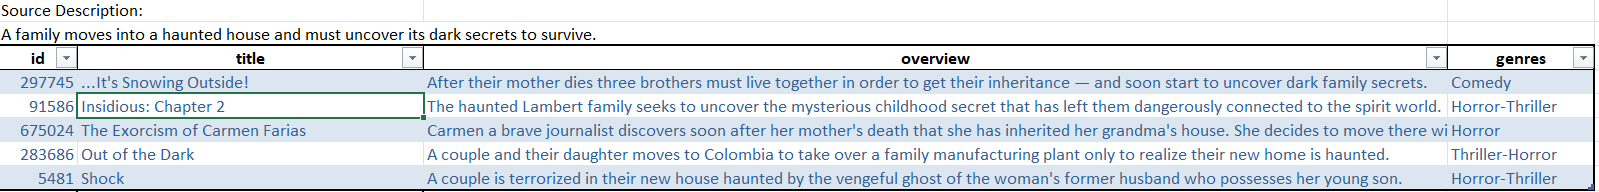

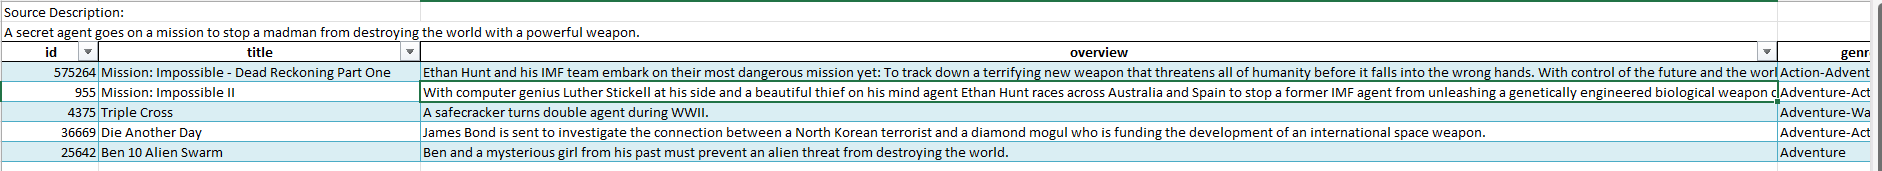

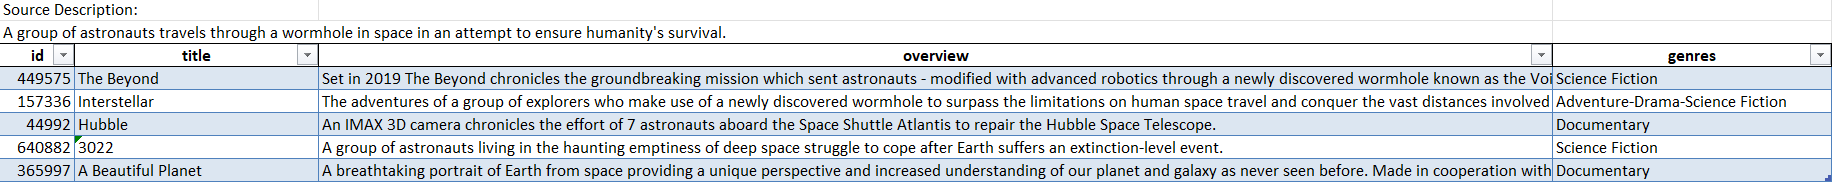

However, when it comes to shorter descriptions or using synonims it is hard for the model to give more relevant suggestions, we should try another way to recommend

## Transformer

We will make use of the transformer library, in order to make more accurate and closer to the meaning recommendations. We should first process the target columns and append them

In [19]:
df = data.copy()

for col in ["overview", "genres", "keywords"]:
    df[col] = df[col].fillna("").astype(str)
    df.loc[df[col].str.lower().eq("nan"), col] = ""

df["genres"] = df["genres"].str.replace("-", " ", regex=False)
df["keywords"] = df["keywords"].str.replace("-", " ", regex=False)

df["combined"] = (df["overview"] + " " + df["genres"] + " " + df["keywords"]).str.strip()
non_str = df["combined"].apply(lambda x: not isinstance(x, str)).sum()
print("Non-strings in combined:", non_str)

Non-strings in combined: 0


In [20]:
st_model = SentenceTransformer("all-MiniLM-L6-v2")
movie_embeddings = st_model.encode(
    df["combined"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6012.38it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 380/380 [04:56<00:00,  1.28it/s]


In [35]:
dimension = movie_embeddings.shape[1] 
index = faiss.IndexFlatIP(dimension)
index.add(movie_embeddings.astype('float32'))

In [36]:
def recommend_transformer(description, top_movies=8):
    description = str(description).strip()
    if not description:
        raise ValueError("Please provide a non-empty description.")

    query_emb = st_model.encode(
        [description],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype('float32')

    distances, indices = index.search(query_emb, k=top_movies)
    top_idx = indices[0]
    out = df.iloc[top_idx][["id", "title", "overview", "genres"]].copy()
    out["score"] = distances[0]
    
    return out

recommend_transformer("Virgin friends comedy", top_movies=8)

,id,title,overview,genres,score
13066,27088,The Last American Virgin,The friendship of a group of young friends str...,Comedy,0.708137
8160,12795,Another Gay Movie,In the dirtiest funniest most scandalous gay-t...,Comedy Romance,0.620252
13179,333549,Among Friends,Three longtime friends set off on a boat trip ...,Comedy,0.615114
13445,249923,Someone Marry Barry,A trio of friends scheme to find a wife for th...,Comedy,0.613909
17741,39800,Life During Wartime,Friends family and lovers struggle to find lov...,Comedy Drama,0.613169
5972,295699,Everybody Wants Some!!,A comedy that follows a group of friends as th...,Comedy,0.612912
9552,99367,Date and Switch,Two guys who make a pact to lose their virgini...,Comedy,0.606814
23531,58204,Love & Slaps,A comedy about generational conflict between t...,Comedy,0.589042


In [22]:
writer = pd.ExcelWriter("SBERT_movie_recommendations.xlsx", engine="openpyxl")

for i, description in enumerate(test_descriptions):
    recs = recommend_transformer(description, top_movies=5)
    sheet_name = f"Rec {i+1}"
    recs.to_excel(writer, sheet_name=sheet_name, index=False, startrow=2)

    ws = writer.sheets[sheet_name]
    ws.cell(row=1, column=1, value="Source Description:")
    ws.cell(row=2, column=1, value=description)

writer.close()
print("Saved to SBERT_movie_recommendations.xlsx")

Saved to SBERT_movie_recommendations.xlsx


It gives good recommendations, as we can see from the excel file.

In [37]:
recommend_transformer("marvel", top_movies=8)

,id,title,overview,genres,score
6281,474227,Inhumans: The First Chapter,An isolated community of superhumans fight to ...,Science Fiction Action Adventure,0.606414
1006,299537,Captain Marvel,The story follows Carol Danvers as she becomes...,Action Adventure Science Fiction,0.602961
376,315635,Spider-Man: Homecoming,Following the events of Captain America: Civil...,Action Adventure Science Fiction Drama,0.582061
13621,413279,Team Thor,Discover what Thor was up to during the events...,Comedy Science Fiction,0.571267
12462,284019,Phineas and Ferb: Mission Marvel,Phineas and Ferb team up with the Avengers to ...,Animation Family Comedy,0.570566
1862,100402,Captain America: The Winter Soldier,After the cataclysmic events in New York with ...,Action Adventure Science Fiction,0.568842
2625,14613,Next Avengers: Heroes of Tomorrow,The children of the Avengers hone their powers...,Animation Family Action Adventure Science Fiction,0.567131
1809,43641,Superman/Shazam!: The Return of Black Adam,Chosen the world’s protector against the Seven...,Animation Action,0.566496


In [38]:
faiss.write_index(index, "movies_v1.index")